# Fase 4 — Clima semanal causal

Se prueban humedad relativa y precipitación en la ventana de cinco semanas terminada en el origen `t−h`. Para `h=4` equivale a `t−8,…,t−4`. Las anomalías se calculan respecto de una climatología distrital y semanal ajustada por separado antes de cada temporada de prueba. La temperatura mínima queda como candidata secundaria. No se utiliza la columna duplicada `lluvia_total_mm`.

La comparación usa conteos de casos porque el umbral de alerta elevada aún está abierto. Ridge es una sonda diagnóstica fija; el primer modelo previsto sigue siendo XGBoost. Las temporadas comparadas son cortes exploratorios, no una selección definitiva de test.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from src.eda.carga import cargar_integrado
from src.modeling.clima import ajustar_climatologia, construir_clima
from src.modeling.diagnostico_clima import contrastar_clima
from src.utils.paths import DOCS, SILVER_INTEGRADO
from src.validation.expectations_integrado import coverage_path, load_case_coverage, validate_complete
SALIDA = DOCS / 'feature_engineering'
METRICAS = SALIDA / 'metricas'
FIGURAS = SALIDA / 'figuras' / 'fase4_clima'
METRICAS.mkdir(parents=True, exist_ok=True)
FIGURAS.mkdir(parents=True, exist_ok=True)

In [2]:
panel = cargar_integrado()
validate_complete(panel, load_case_coverage(coverage_path(SILVER_INTEGRADO)))
# Verificación independiente: una media de 5 semanas del distrito 200101.
corte_ejemplo = pd.Timestamp('2022-08-06')
ajuste = ajustar_climatologia(panel, corte_ejemplo)
features = construir_clima(panel, 4, ajuste)
d = panel.loc[panel.ubigeo.eq('200101')].reset_index(drop=True)
f = features.loc[features.ubigeo.eq('200101')].reset_index(drop=True)
i = 250
esperada = d.loc[i-8:i-4, 'hum_rel_media'].mean()
observada = f.loc[i, 'hum_rel_media_media5_h4']
assert np.isclose(esperada, observada)
assert len(features) == len(panel) and not features.duplicated(['ubigeo','anio','semana']).any()
assert not any('lluvia_total_mm' in c for c in features)
print({'filas': len(panel), 'distritos': panel.ubigeo.nunique(), 'humedad_ventana_manual': round(esperada, 5), 'humedad_feature': round(observada, 5)})

{'filas': 30485, 'distritos': 65, 'humedad_ventana_manual': np.float64(66.34286), 'humedad_feature': np.float64(66.34286)}


modelo               historia_calendario  historia_calendario_clima  \
horizonte temporada                                                   
2         2022                     1.981                      2.080   
          2023                    11.509                     11.130   
          2024                     4.896                      4.997   
          2025                     0.459                      0.456   
4         2022                     2.535                      2.649   
          2023                    15.421                     14.846   
          2024                     6.776                      6.682   
          2025                     0.534                      0.526   

modelo               persistencia  delta_clima_menos_base  
horizonte temporada                                        
2         2022              1.959                   0.099  
          2023             10.837                  -0.379  
          2024              4.956                   0.101  
          2025              0.467                  -0.003  
4         2022              2.846                   0.114  
          2023             17.680                  -0.575  
          2024              7.848                  -0.095  
          2025              0.499                  -0.008

horizonte  temporada
2          2022        -0.007
           2023         0.185
           2024         0.010
           2025        -0.002
4          2022         0.004
           2023         0.128
           2024         0.000
           2025        -0.004
Name: delta_temp_min_menos_dos_variables, dtype: float64

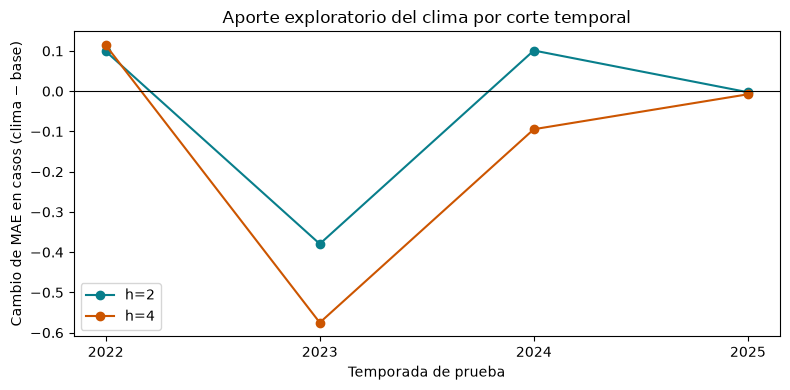

In [3]:
resultados = contrastar_clima(panel)
tabla = resultados.pivot(index=['horizonte', 'temporada'], columns='modelo', values='mae_casos')
tabla['delta_clima_menos_base'] = tabla['historia_calendario_clima'] - tabla['historia_calendario']
display(tabla.round(3))
# Sensibilidad: temperatura mínima junto a humedad y precipitación.
resultados_temp = contrastar_clima(panel, variables_clima=('hum_rel_media', 'precip_total_mm', 'temp_min'))
tabla_temp = resultados_temp.pivot(index=['horizonte', 'temporada'], columns='modelo', values='mae_casos')
sensibilidad = (tabla_temp['historia_calendario_clima'] - tabla['historia_calendario_clima']).rename('delta_temp_min_menos_dos_variables')
display(sensibilidad.round(3))
metrica = {'descripcion': 'Ridge diagnóstico fijo; train antes del primer origen de cada temporada; MAE en casos y log1p', 'ventana_clima': 't-h-4 a t-h, 5 semanas', 'variables': ['hum_rel_media', 'precip_total_mm'], 'variable_sensibilidad': 'temp_min', 'filas_panel': len(panel), 'distritos': int(panel.ubigeo.nunique()), 'filas_features_h4': len(features), 'primeras_filas_sin_ventana_por_distrito_h4': 8, 'verificacion_media_h4': {'esperada': float(esperada), 'observada': float(observada)}, 'resultados': resultados.to_dict(orient='records'), 'resultados_con_temp_min': resultados_temp.to_dict(orient='records')}
(METRICAS / 'fase4_clima.json').write_text(json.dumps(metrica, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
fig, ax = plt.subplots(figsize=(8, 4))
for h, color in [(2, '#087e8b'), (4, '#cc5500')]:
    sub = tabla.xs(h, level='horizonte')
    ax.plot(sub.index, sub.delta_clima_menos_base, marker='o', label=f'h={h}', color=color)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks([2022, 2023, 2024, 2025])
ax.set(xlabel='Temporada de prueba', ylabel='Cambio de MAE en casos (clima − base)', title='Aporte exploratorio del clima por corte temporal')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURAS / '01_ablacion_mae_clima.png', dpi=140)
plt.show()

## Lectura

Un delta negativo indica una mejora del modelo diagnóstico respecto de historia y calendario. La persistencia es una referencia adicional. La climatología y los escaladores de Ridge se ajustan antes del bloque de prueba; dentro de él, cada fila solo toma clima observado hasta su origen. Estos resultados no seleccionan variables finales ni definen el umbral de alerta.